In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw
from collections import Counter

plt.rcParams['figure.dpi'] = 300

In [5]:
# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/notebooks'
PATH_TO_DOCKING_RESULTS_ORIGINAL = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
PATH_TO_DOCKING_RESULTS_REAL = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'docking_results')
PATH_TO_INPUT_LIGANDS = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'input_ligands')
PATH_TO_DOCKING_RESULTS_REAL_2 = os.path.join(root, "..", "processed", "unidock_REAL_docking_2", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [6]:
DOCKING_RESULTS_REAL_2 = {}
DOCKING_RESULTS_ORIGINAL = {}
DOCKING_RESULTS_REAL = {}
DOCKING_RESULTS_REAL_BACKGROUND = {}

# For each pocket - REAL 2
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL_2))):
    try:
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL_2, pocket, 'report.csv'))
        if len(scores) == 99105:
            DOCKING_RESULTS_REAL_2[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}
        else:
            print(pocket, len(scores))
    except:
        pass

# For each pocket - ORIGINAL
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_ORIGINAL))):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_ORIGINAL, pocket, 'report.csv'))
    assert len(scores) == 100154
    DOCKING_RESULTS_ORIGINAL[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# For each pocket - REAL
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL))):
    lines = open(os.path.join(PATH_TO_INPUT_LIGANDS, f"input_ligands_{pocket}.txt"), "r").readlines()
    lines = [i.strip().replace(".sdf", "").split("/")[-1] for i in lines]
    actives = set(lines[:100000])
    inactives = set(lines[100000:])
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL, pocket, 'report.csv'))
    scores['set'] = ["inactive" if i in inactives else "active" for i in scores['compound']]
    scores_actives = scores[scores['set'] == 'active'].reset_index(drop=True)
    scores_inactives = scores[scores['set'] == 'inactive'].reset_index(drop=True)
    DOCKING_RESULTS_REAL[pocket] = {i: j for i, j in zip(scores_actives['compound'], scores_actives['score'])}
    DOCKING_RESULTS_REAL_BACKGROUND[pocket] = {i: j for i, j in zip(scores_inactives['compound'], scores_inactives['score'])}

 25%|██▌       | 62/244 [00:02<00:07, 24.14it/s]

alphafold3_P9WFS9_model_3_pocket_5 28102


 66%|██████▋   | 162/244 [00:06<00:03, 25.19it/s]

chai1_P9WFT5_model_3_pocket_2 20455


100%|██████████| 276/276 [00:32<00:00,  8.45it/s]


In [8]:
Counter([len(DOCKING_RESULTS_ORIGINAL[i]) for i in DOCKING_RESULTS_ORIGINAL])

Counter({100154: 276})

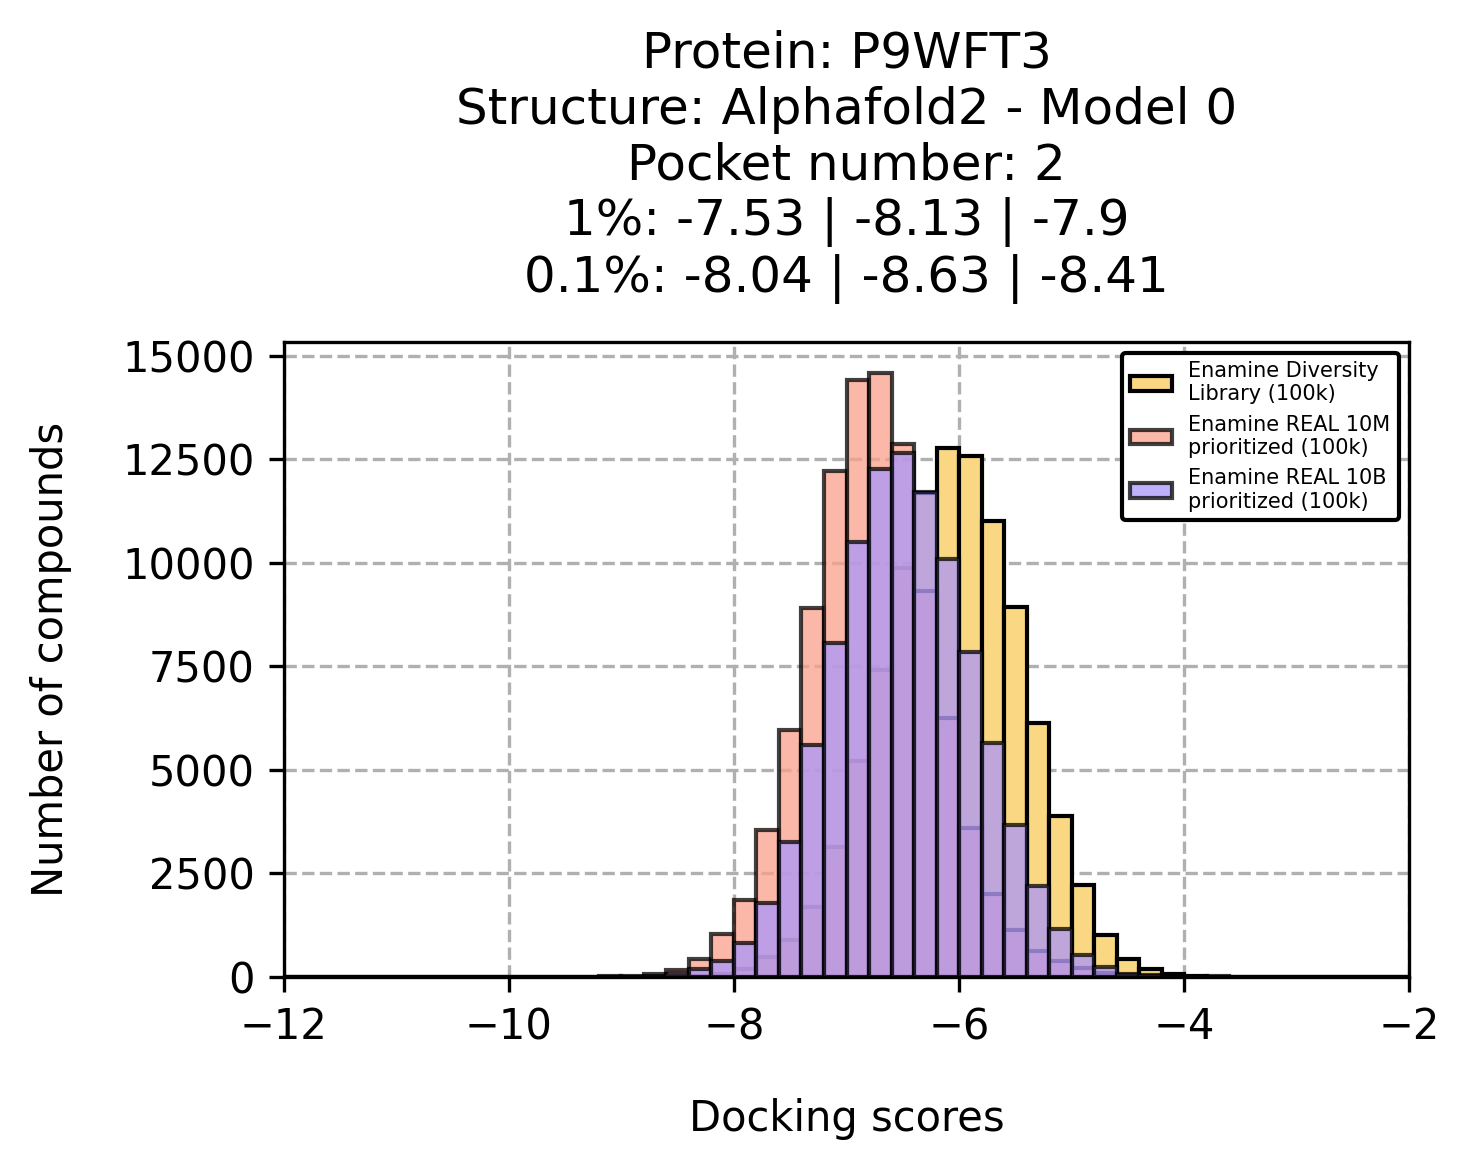

In [9]:
pocket = 'alphafold2_P9WFT3_model_0_pocket_2'
# pocket = "alphafold2_P9WFS9_model_0_pocket_1"
bins = [i for i in np.arange(-14, 1, 0.2)]

y1 = list(DOCKING_RESULTS_ORIGINAL[pocket].values())
y2 = list(DOCKING_RESULTS_REAL[pocket].values())
y3 = list(DOCKING_RESULTS_REAL_2[pocket].values())
p = f"Protein: {pocket.split('_')[1]}\nStructure: {pocket.split('_')[0].capitalize()} - Model {pocket.split('_')[3]}\nPocket number: {pocket.split('_')[-1]}"
title = f"{p}\n1%: {round(np.percentile(y1, 1), 2)} | {round(np.percentile(y2, 1), 2)} | {round(np.percentile(y3, 1), 2)}\n0.1%: \
{round(np.percentile(y1, 0.1), 2)} | {round(np.percentile(y2, 0.1), 2)} | {round(np.percentile(y3, 0.1), 2)}"



plt.figure(figsize=(5, 4))
plt.hist(y1, bins=bins, zorder=2, edgecolor='k', color="#FAD782", label='Enamine Diversity\nLibrary (100k)')
plt.hist(y2, bins=bins, zorder=2, edgecolor='k', color="#FAA08B", label='Enamine REAL 10M\nprioritized (100k)', alpha=0.75)
plt.hist(y3, bins=bins, zorder=2, edgecolor='k', color="#AA96FA", label='Enamine REAL 10B\nprioritized (100k)', alpha=0.75)
plt.grid(linestyle='--', zorder=-2)
plt.xlim([-12, -2])
plt.xlabel("Docking scores", labelpad=12)
plt.ylabel("Number of compounds", labelpad=12)
plt.legend(loc='best', framealpha=1, edgecolor='k', prop={'size': 5})
plt.title(title, pad=12)
plt.tight_layout()
plt.show()

In [10]:
### BOXPLOTS ###

In [11]:
def simple_boxplot(ax, x, y, c, width):
    lw = 0.1
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[1, 99], showfliers=False,
               boxprops=dict(facecolor=c, color='black', lw=lw),
               medianprops=dict(color='black', lw=lw),
               whiskerprops=dict(color='black', lw=lw),
               capprops=dict(color='none', lw=lw))
    
def simple_boxplot_label(ax, x, y, c, width, label):
    lw = 0.1
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[1, 99], showfliers=False, label=label,
               boxprops=dict(facecolor=c, color='black', lw=lw),
               medianprops=dict(color='black', lw=lw),
               whiskerprops=dict(color='black', lw=lw),
               capprops=dict(color='none', lw=lw))

In [15]:
ind = np.argsort([np.median(list(DOCKING_RESULTS_ORIGINAL[x].values())) for x in sorted(DOCKING_RESULTS_ORIGINAL)])
ind_100 = np.argsort([sorted(DOCKING_RESULTS_ORIGINAL[x].values())[99] for x in sorted(DOCKING_RESULTS_ORIGINAL)])

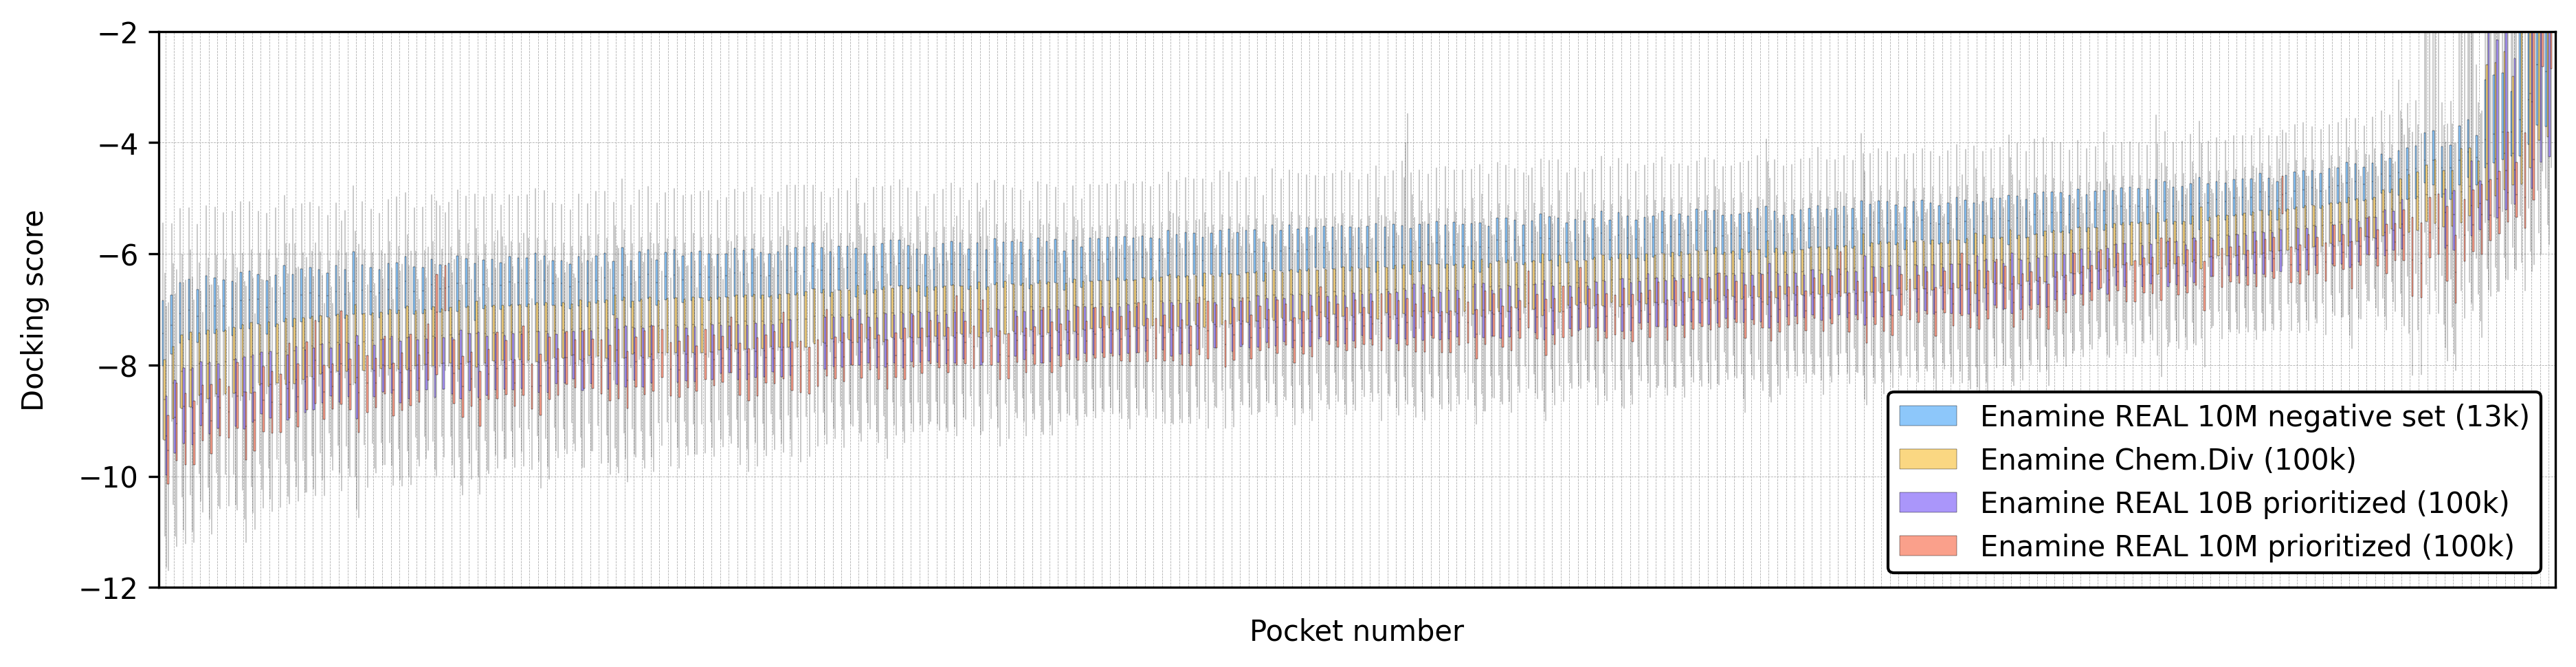

In [13]:
fig, ax = plt.subplots(figsize=(15, 3.5))

for c, pock in enumerate(np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind]):
    w = 0.2
    if c != 2:
        simple_boxplot(ax, c-3*w/2, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w)
        simple_boxplot(ax, c-w/2, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w)
        try:
            simple_boxplot(ax, c+w/2, DOCKING_RESULTS_REAL_2[pock].values(), c="#AA96FA", width=w)
        except:
            pass
        simple_boxplot(ax, c+3*w/2, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w)
        
    else:
        simple_boxplot_label(ax, c-3*w/2, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w, label="Enamine REAL 10M negative set (13k)")
        simple_boxplot_label(ax, c-w/2, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w, label=f"Enamine Chem.Div (100k)")
        simple_boxplot_label(ax, c+w/2, DOCKING_RESULTS_REAL_2[pock].values(), c="#AA96FA", width=w, label="Enamine REAL 10B prioritized (100k)")
        simple_boxplot_label(ax, c+3*w/2, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w, label="Enamine REAL 10M prioritized (100k)")
        

plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], [pock.replace("_model", "\nmodel") for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], ["" for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)
plt.legend(framealpha=1, edgecolor='k')
plt.ylim([-12, -2])
plt.show()

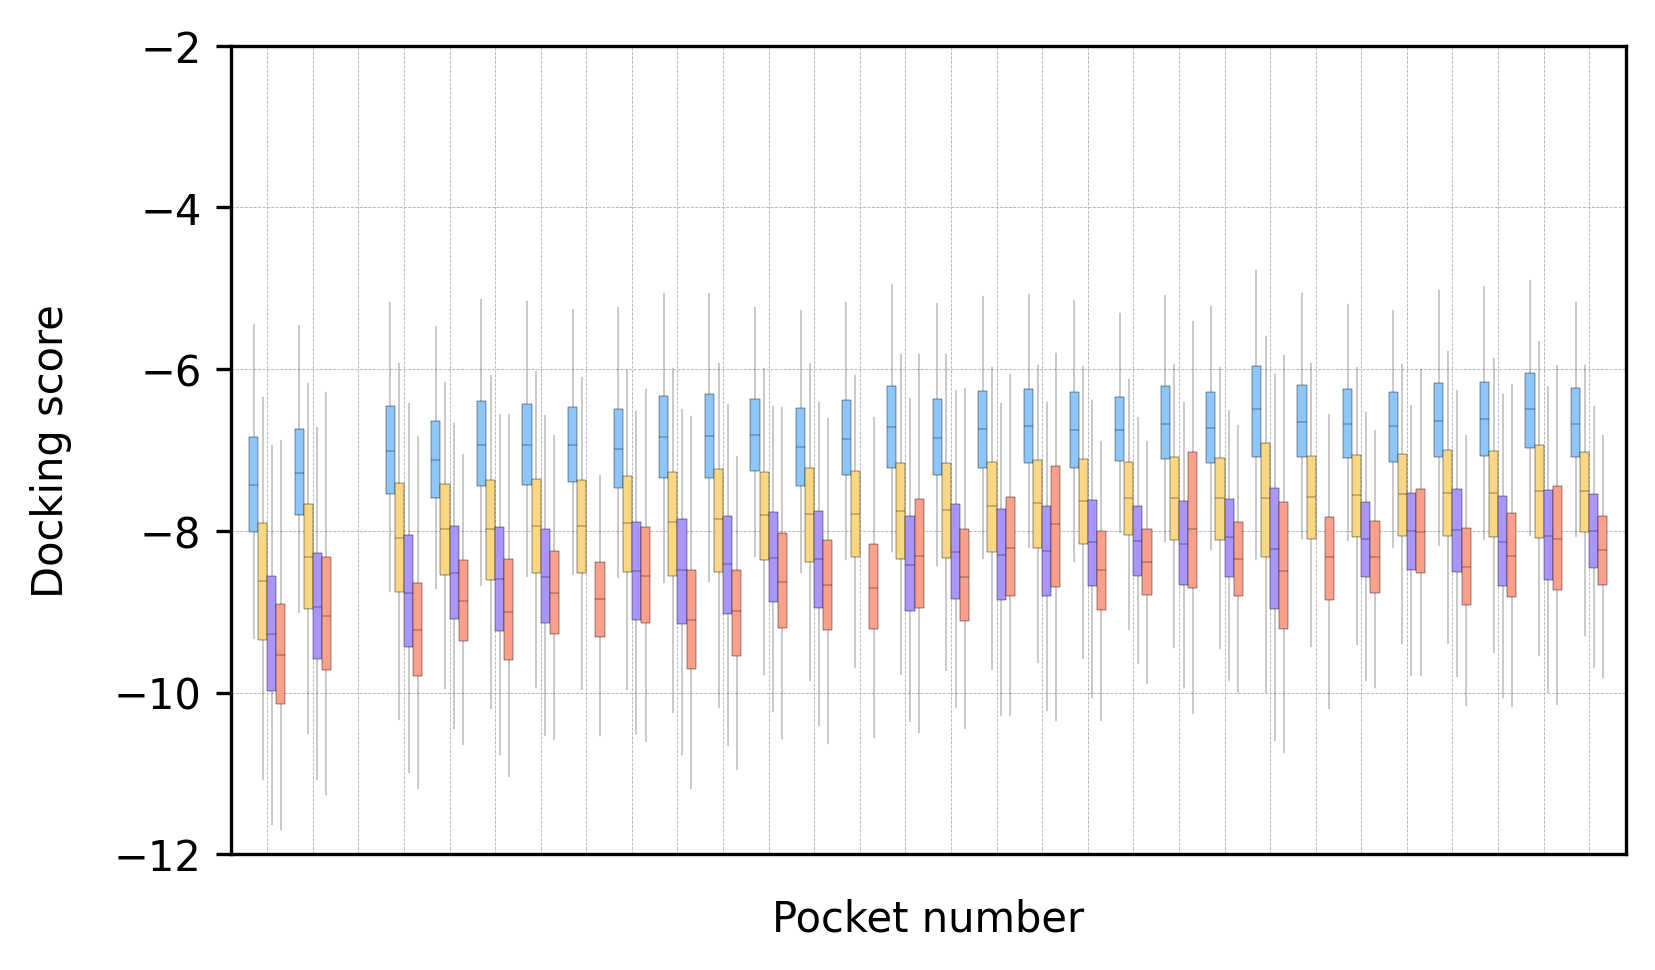

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.5))

for c, pock in enumerate(np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind][:30]):
    w = 0.2
    if c != 2:
        simple_boxplot(ax, c-3*w/2, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w)
        simple_boxplot(ax, c-w/2, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w)
        try:
            simple_boxplot(ax, c+w/2, DOCKING_RESULTS_REAL_2[pock].values(), c="#AA96FA", width=w)
        except:
            pass
        simple_boxplot(ax, c+3*w/2, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w)

# plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], [pock.replace("_model", "\nmodel") for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))][:30], ["" for i in sorted(DOCKING_RESULTS_ORIGINAL)][:30], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)
# plt.legend(framealpha=1, edgecolor='k')
plt.ylim([-12, -2])
plt.show()

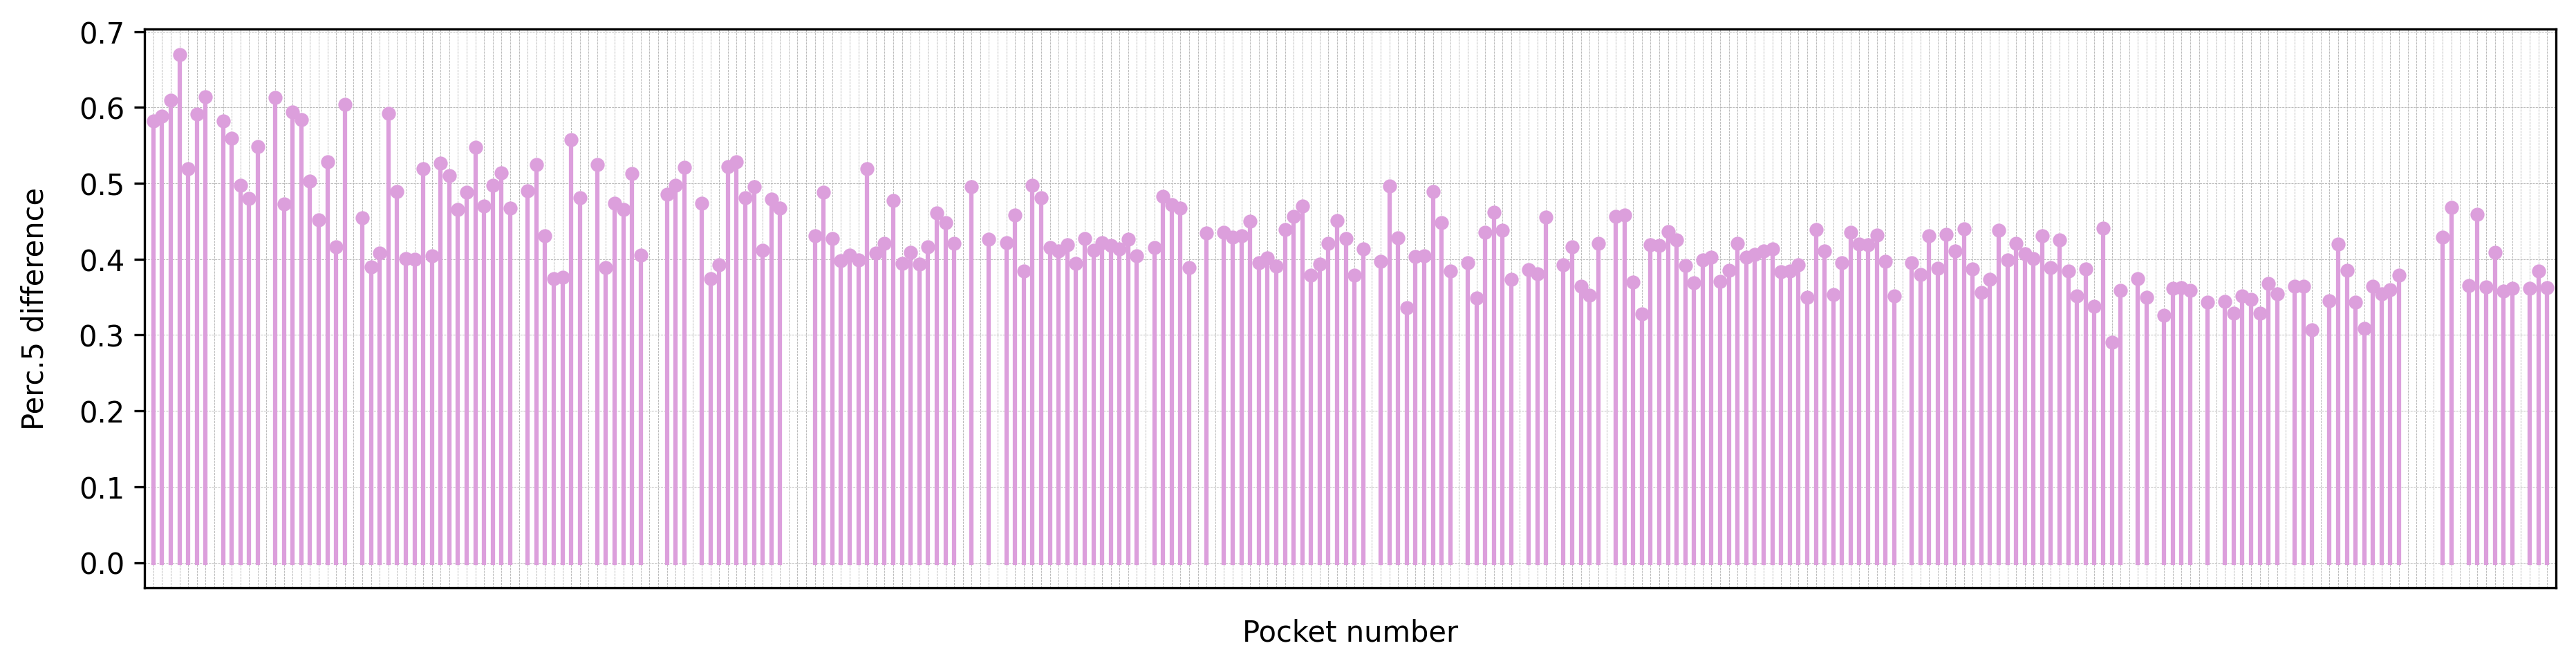

In [21]:
fig, ax = plt.subplots(figsize=(15, 3.5))

perc = 5

for c, pock in enumerate(np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind]):

    try:
        perc1 = np.percentile(list(DOCKING_RESULTS_ORIGINAL[pock].values()), perc)
        perc2 = np.percentile(list(DOCKING_RESULTS_REAL_2[pock].values()), perc)
        diff = perc1 - perc2
        ax.scatter(c, diff, zorder=2, c='#DC9FDC', s=15)
        ax.plot([c, c], [diff, 0], color='#DC9FDC')
    except:
        pass
 

plt.xlim([-1, c+1])
plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], ["" for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel(f"Perc.{perc} difference", labelpad=10)
plt.show()

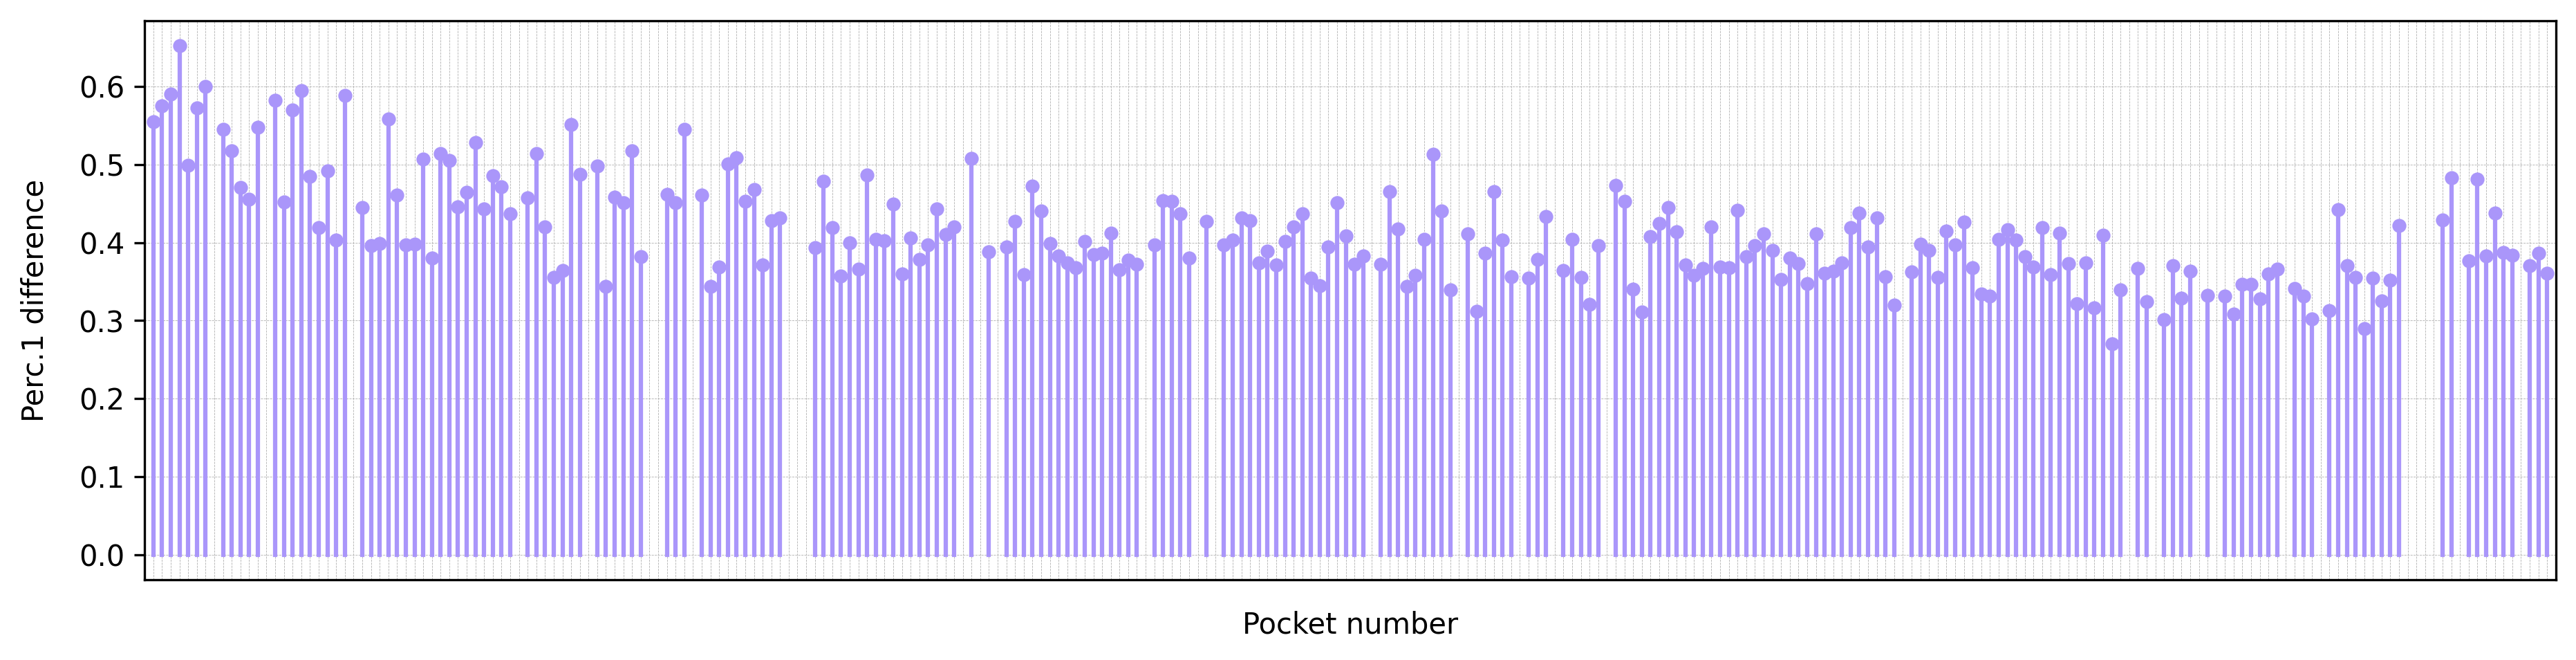

In [22]:
fig, ax = plt.subplots(figsize=(15, 3.5))

perc = 1

for c, pock in enumerate(np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind]):

    try:
        perc1 = np.percentile(list(DOCKING_RESULTS_ORIGINAL[pock].values()), perc)
        perc2 = np.percentile(list(DOCKING_RESULTS_REAL_2[pock].values()), perc)
        diff = perc1 - perc2
        ax.scatter(c, diff, zorder=2, c='#AA96FA', s=15)
        ax.plot([c, c], [diff, 0], color='#AA96FA')
    except:
        pass
 

plt.xlim([-1, c+1])
plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], ["" for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel(f"Perc.{perc} difference", labelpad=10)
plt.show()